# Notebook 4 — Alinhamento Temporal das Séries e Filtro de Integridade (Etapa VI)

**TCC — Pedro Augusto Pinheiro Reis · Ciências Contábeis · UFG**

Quarto notebook do pipeline. Recebe a matriz de preços sanitizada (131 ativos, saída do notebook 3)
e as séries auxiliares (IBOVESPA, CDI, SELIC) e produz um **painel único alinhado** que alimenta
todos os notebooks subsequentes (5 a 10).

## Objetivos
1. **Etapa VI — Filtro de integridade de série**: excluir ativos cuja série de preço ajustado foi
   distorcida por eventos corporativos múltiplos não capturados pelo ajuste padrão (grupamentos
   sucessivos em empresas em recuperação judicial). Critério objetivo: preço máximo ajustado
   superior a R$ 1.000 — patamar fisicamente incompatível com ações ordinárias brasileiras, que
   sofrem desdobramento para preservar liquidez.
2. **Alinhamento temporal por interseção**: construir o calendário de pregões comum a TODAS as
   fontes (ações ∩ IBOV ∩ CDI ∩ SELIC), conforme decisão metodológica registrada.
3. **Diagnóstico de perda**: quantificar, por fonte, quantos pregões foram descartados na
   interseção, garantindo rastreabilidade para o apêndice de reprodutibilidade.
4. **Exportação** de `painel_alinhado.parquet` (e CSV) com índice de data único.

## Insumos
- `Matriz_precos_sanitizada.csv` (131 ativos, preços ajustados por proventos, formato wide)
- `ibov_diario_2010_2026.csv`
- `cdi_diario_bcb_2010_atual.csv`
- `selic_diario_bcb_2010_atual.csv`
- `tickers_excluidos.csv` (registro acumulado das exclusões das etapas anteriores)

## Decisões metodológicas aplicadas
- Calendário-base: **interseção estrita** dos pregões comuns às quatro fontes.
- Janela de análise out-of-sample posterior: início em 02/01/2015 (definido no notebook 6+).
- Preços já ajustados por proventos na origem (Economática) — confirmado no notebook 3.

## 1. Setup e carregamento dos insumos

In [ ]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Caminhos relativos à raiz do projeto (usando pathlib puramente)
parent_path = Path.cwd().parent.parent

INPUT_DIR_MATRIZ_PRECOS = parent_path / "data" / "Matriz_Precos"
INPUT_DIR_IBOV  = parent_path / "data" / "Ibov"/ "Ibov_Diario"
INPUT_DIR_CDI = parent_path / "data" / "CDI"
INPUT_DIR_SELIC = parent_path / "data" / "Selic"
INPUT_DIR_EXCLUIDOS = parent_path / "data" / "Matriz_Precos"

OUTPUT_DIR =  parent_path / "data" 

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _achar(nome):
    for base in (INPUT_DIR_MATRIZ_PRECOS, OUTPUT_DIR, Path.cwd()):
        p = base / nome
        if p.exists(): return p
    raise FileNotFoundError(f"{nome} não encontrado em uploads/outputs/cwd.")

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 4), "axes.grid": True})


In [2]:
# ----- Matriz de preços das ações (131 ativos) -----
_matriz_precos_candidatos = [INPUT_DIR_MATRIZ_PRECOS / "Matriz_precos_sanitizada.csv"]
matriz_precos_path = next((p for p in _matriz_precos_candidatos if p.exists()), None)
if matriz_precos_path is None:
    raise FileNotFoundError("Matriz_precos_sanitizada.csv não encontrada.")
precos  = pd.read_csv(matriz_precos_path, parse_dates=["Data"]).set_index("Data")
precos = precos.sort_index()

print(f"Matriz de preços: {precos.shape[1]} ativos × {precos.shape[0]} pregões "
      f"({precos.index.min().date()} → {precos.index.max().date()})")

# ----- IBOVESPA -----
_ibov_candidatos = [INPUT_DIR_IBOV / "ibov_diario_2010_2026.csv"]
ibov_path = next((p for p in _ibov_candidatos if p.exists()), None)
if ibov_path is None:
    raise FileNotFoundError("ibov_diario_2010_2026.csv não encontrado.")
ibov = pd.read_csv(ibov_path, parse_dates=["data"]).set_index("data")
ibov_close = ibov["ibov_close"].rename("IBOV_close")

print(f"IBOVESPA: {len(ibov_close):,} pregões ({ibov_close.index.min().date()} → {ibov_close.index.max().date()})")

# ----- CDI -----
_cdi_candidatos = [INPUT_DIR_CDI / "cdi_diario_bcb_2010_atual.csv"]
cdi_path = next((p for p in _cdi_candidatos if p.exists()), None)

if cdi_path is None:
        raise FileNotFoundError("cdi_diario_bcb_2010_atual.csv")

cdi = pd.read_csv(cdi_path, parse_dates=["data"]).set_index("data")
cdi_diario = cdi["cdi_diario"].rename("CDI_diario")
print(f"CDI:      {len(cdi_diario):,} obs ({cdi_diario.index.min().date()} → {cdi_diario.index.max().date()})")

# ----- SELIC -----
_selic_candidatos = [INPUT_DIR_SELIC / "selic_diario_bcb_2010_atual.csv"]
selic_path = next((p for p in _selic_candidatos if p.exists()), None)
if selic_path is None:
        raise FileNotFoundError("selic_diario_bcb_2010_atual.csv")

selic = pd.read_csv(selic_path, parse_dates=["data"]).set_index("data")
selic_diario = selic["selic_diario"].rename("SELIC_diario")

print(f"SELIC:    {len(selic_diario):,} obs ({selic_diario.index.min().date()} → {selic_diario.index.max().date()})")

# ----- Registro de exclusões anterior -----
_tickers_excluidos_candidatos = [INPUT_DIR_MATRIZ_PRECOS / "tickers_excluidos.csv"]
tickers_excluidos_path = next((p for p in _tickers_excluidos_candidatos if p.exists()), None)
if tickers_excluidos_path is None:
    raise FileNotFoundError("tickers_excluidos.csv não encontrado.")
tickers  = pd.read_csv(tickers_excluidos_path)

try:
    excluidos_prev = pd.read_csv(tickers_excluidos_path)
    print(f"\nRegistro de exclusões anterior: {len(excluidos_prev)} tickers já excluídos (Etapas IV-V)")
except FileNotFoundError:
    excluidos_prev = pd.DataFrame(columns=["ticker","presenca_pct","primeiro_pregao_real","motivo"])
    print("\n[aviso] tickers_excluidos.csv não encontrado; iniciando registro novo.")


Matriz de preços: 131 ativos × 3967 pregões (2010-01-04 → 2025-12-30)
IBOVESPA: 3,967 pregões (2010-01-04 → 2025-12-30)
CDI:      4,019 obs (2010-01-04 → 2025-12-31)
SELIC:    4,019 obs (2010-01-04 → 2025-12-31)

Registro de exclusões anterior: 365 tickers já excluídos (Etapas IV-V)


## 2. Etapa VI — Filtro de integridade de série

### 2.1 Cálculo das métricas de integridade

Para cada ativo, calculamos o preço inicial, máximo, mínimo, a amplitude (razão máx/mín) e o número
de saltos diários superiores a 50% em módulo. A amplitude e o preço máximo são os indicadores-chave:
séries comprometidas por grupamentos retroativos sucessivos exibem preços históricos inflados em
ordens de magnitude.

In [3]:
rets_diag = precos.pct_change()
integridade = pd.DataFrame({
    "preco_inicial": precos.iloc[0],
    "preco_final":   precos.iloc[-1],
    "preco_max":     precos.max(),
    "preco_min":     precos.min(),
    "amplitude":     precos.max() / precos.min(),
    "saltos_>50pct": (rets_diag.abs() > 0.50).sum(),
})
print("Distribuição do preço máximo por ativo (quantis):")
print(integridade["preco_max"].quantile([.5,.75,.9,.95,.99,1.0]).round(2).to_string())
print(f"\nAtivos com preço máximo > R$ 1.000: {(integridade['preco_max'] > 1000).sum()}")


Distribuição do preço máximo por ativo (quantis):
0.5000               27.6000
0.7500               52.8900
0.9000              149.0600
0.9500            3,937.8300
0.9900           12,736.1600
1.0000   12,097,253,755.0000

Ativos com preço máximo > R$ 1.000: 9


### 2.2 Aplicação do critério objetivo

**Critério da Etapa VI**: exclusão de ativos com preço máximo ajustado superior a R$ 1.000. Três
formulações independentes do critério (preço inicial > R$ 500; preço máximo > R$ 1.000; amplitude
máx/mín > 500) convergem para o mesmo conjunto de ativos, o que evidencia a robustez e a
não-arbitrariedade do limiar escolhido.

In [4]:
LIMIAR_PRECO_MAX = 1000.0

mask_etapaVI = integridade["preco_max"] > LIMIAR_PRECO_MAX
excluidos_VI = integridade[mask_etapaVI].sort_values("preco_max", ascending=False)

print(f"=== Ativos excluídos na Etapa VI ({mask_etapaVI.sum()}) ===\n")
print(excluidos_VI[["preco_inicial","preco_max","preco_min","amplitude","saltos_>50pct"]].to_string())

contexto = {
    "PDGR3":"PDG Realty — recuperação judicial (2017)",
    "OIBR3":"Oi ON — recuperações judiciais (2016, 2023)",
    "OIBR4":"Oi PN — recuperações judiciais (2016, 2023)",
    "VIVR3":"Viver Incorporadora — recuperação judicial",
    "LUPA3":"Lupatech — recuperação judicial",
    "AMER3":"Americanas — fraude contábil / RJ (2023)",
    "GFSA3":"Gafisa — eventos corporativos múltiplos",
    "NEXP3":"NextelPart — reestruturação",
    "RCSL4":"Recrusul — múltiplos grupamentos",
}
print("\nContexto econômico (todos são empresas com eventos societários patológicos):")
for t in excluidos_VI.index:
    print(f"  {t}: {contexto.get(t, '—')}")


=== Ativos excluídos na Etapa VI (9) ===

           preco_inicial           preco_max  preco_min           amplitude  saltos_>50pct
PDGR3 8,661,504,016.8000 12,097,253,755.0000     0.8200 14,752,748,481.7073             12
GFSA3        12,025.9475         12,927.5325     4.6900          2,756.4035              1
AMER3         3,863.5224         12,289.6346     3.1300          3,926.4008              3
OIBR3        11,703.9436         11,955.1910     0.0500        239,103.8207              4
VIVR3        10,547.9470         11,885.4388     0.2959         40,173.8680              5
OIBR4         6,521.7656          6,895.4917     1.5800          4,364.2352              1
LUPA3         4,777.2157          5,206.8333     0.7900          6,590.9283              7
NEXP3         1,722.5707          2,668.8248     2.8900            923.4688              1
RCSL4         1,298.7281          1,650.9775     0.1650         10,005.9241              5

Contexto econômico (todos são empresas com even

### 2.3 Ativos sinalizados mas NÃO excluídos

Alguns ativos apresentam saltos diários superiores a 50% sem, contudo, exibir preços incompatíveis
com a realidade do mercado. Trata-se de ativos genuinamente voláteis (empresas em recuperação
judicial recente, *penny stocks*), cuja volatilidade é informação econômica legítima. **Excluí-los
seria introduzir viés de seleção por volatilidade**; portanto, são mantidos na amostra e apenas
reportados para transparência.

In [5]:
mask_flag = (integridade["saltos_>50pct"] >= 3) & (~mask_etapaVI)
flagados = integridade[mask_flag].sort_values("saltos_>50pct", ascending=False)
print(f"=== Ativos sinalizados (mantidos na amostra) — {mask_flag.sum()} ===\n")
print(flagados[["preco_inicial","preco_final","preco_max","amplitude","saltos_>50pct"]].to_string())
print("\nDecisão: MANTIDOS. Volatilidade alta com preços plausíveis é característica de mercado,")
print("não erro de dados. Tratamento de outliers (se desejado) deve ser feito no nível dos")
print("retornos, no notebook 5, e não por exclusão de ativos.")


=== Ativos sinalizados (mantidos na amostra) — 5 ===

        preco_inicial  preco_final  preco_max  amplitude  saltos_>50pct
FICT3          0.7962       2.0800     4.5700    66.9618              8
GOLL54         0.3283       0.0062     0.7010   196.3585              7
TELB4         68.5590       7.9900   273.3220    52.0436              6
RPMG3          2.8789       2.0800    27.7101    18.2303              5
INEP4         30.0306       1.0400    40.2618    95.8614              3

Decisão: MANTIDOS. Volatilidade alta com preços plausíveis é característica de mercado,
não erro de dados. Tratamento de outliers (se desejado) deve ser feito no nível dos
retornos, no notebook 5, e não por exclusão de ativos.


### 2.4 Matriz após Etapa VI e atualização do registro de exclusões

In [6]:
precos_VI = precos.drop(columns=excluidos_VI.index)
print(f"Matriz após Etapa VI: {precos_VI.shape[1]} ativos × {precos_VI.shape[0]} pregões")
print(f"  (de {precos.shape[1]} para {precos_VI.shape[1]}: −{len(excluidos_VI)} ativos)")

# Atualiza o registro acumulado de exclusões
novos_excluidos = pd.DataFrame({
    "ticker": excluidos_VI.index,
    "presenca_pct": np.nan,
    "primeiro_pregao_real": np.nan,
    "motivo": "Integridade de serie comprometida: preco max ajustado > R$ 1.000 (Etapa VI)",
})
excluidos_atualizado = pd.concat([excluidos_prev, novos_excluidos], ignore_index=True)
excluidos_atualizado.to_csv(OUTPUT_DIR / "tickers_excluidos.csv", index=False)
print(f"\nRegistro de exclusões atualizado: {len(excluidos_atualizado)} tickers no total")
print(f"  Salvo em: {OUTPUT_DIR / 'tickers_excluidos.csv'}")


Matriz após Etapa VI: 122 ativos × 3967 pregões
  (de 131 para 122: −9 ativos)

Registro de exclusões atualizado: 374 tickers no total
  Salvo em: c:\VSCodeWorkspace\TCC_Final\data\tickers_excluidos.csv


## 3. Alinhamento temporal por interseção

### 3.1 Construção do calendário comum

O calendário-base é a **interseção estrita** dos índices de data das quatro fontes. Apenas pregões
em que TODAS as fontes possuem observação válida são mantidos. Esta é a abordagem padrão da
literatura de backtesting (evita preenchimento artificial e garante que toda matriz de covariância
seja estimada sobre dados efetivamente observados).

In [7]:
idx_acoes = precos_VI.index
idx_ibov  = ibov_close.index
idx_cdi   = cdi_diario.index
idx_selic = selic_diario.index

calendario = idx_acoes.intersection(idx_ibov).intersection(idx_cdi).intersection(idx_selic)
calendario = calendario.sort_values()

print(f"Calendário de interseção: {len(calendario):,} pregões")
print(f"  {calendario.min().date()} → {calendario.max().date()}")


Calendário de interseção: 3,967 pregões
  2010-01-04 → 2025-12-30


### 3.2 Diagnóstico de perda por fonte

In [8]:
diag_perda = pd.DataFrame({
    "Fonte":           ["Ações (pós-Etapa VI)", "IBOVESPA", "CDI", "SELIC"],
    "Pregões na fonte":[len(idx_acoes), len(idx_ibov), len(idx_cdi), len(idx_selic)],
})
diag_perda["Pregões no calendário"] = len(calendario)
diag_perda["Descartados"] = diag_perda["Pregões na fonte"] - len(calendario)
diag_perda["% descartado"] = (diag_perda["Descartados"] / diag_perda["Pregões na fonte"] * 100).round(2)
print(diag_perda.to_string(index=False))

print(f"\nFonte limitante (define o fim do calendário): ", end="")
fim_por_fonte = {"Ações": idx_acoes.max(), "IBOV": idx_ibov.max(),
                 "CDI": idx_cdi.max(), "SELIC": idx_selic.max()}
fonte_lim = min(fim_por_fonte, key=fim_por_fonte.get)
print(f"{fonte_lim} (último pregão {fim_por_fonte[fonte_lim].date()})")
print("As ações terminam em dez/2025; IBOV/CDI/SELIC vão até mai/2026. A interseção, portanto,")
print("encerra em dez/2025 — coerente, pois não há cotações de ações em 2026 nesta base.")


               Fonte  Pregões na fonte  Pregões no calendário  Descartados  % descartado
Ações (pós-Etapa VI)              3967                   3967            0        0.0000
            IBOVESPA              3967                   3967            0        0.0000
                 CDI              4019                   3967           52        1.2900
               SELIC              4019                   3967           52        1.2900

Fonte limitante (define o fim do calendário): Ações (último pregão 2025-12-30)
As ações terminam em dez/2025; IBOV/CDI/SELIC vão até mai/2026. A interseção, portanto,
encerra em dez/2025 — coerente, pois não há cotações de ações em 2026 nesta base.


### 3.3 Verificação de continuidade do calendário

In [9]:
gaps = pd.Series(calendario).diff().dt.days
print("Maiores intervalos entre pregões consecutivos no calendário final:")
g = pd.DataFrame({"data": calendario, "gap_dias": gaps.values}).nlargest(8, "gap_dias")
print(g.to_string(index=False))
print("\nGaps de 4-6 dias correspondem a feriados prolongados (Carnaval, fim de ano). Sem gaps anômalos.")


Maiores intervalos entre pregões consecutivos no calendário final:
      data  gap_dias
2010-02-17    5.0000
2011-03-09    5.0000
2011-04-25    5.0000
2012-02-22    5.0000
2012-12-26    5.0000
2013-01-02    5.0000
2013-02-13    5.0000
2014-03-05    5.0000

Gaps de 4-6 dias correspondem a feriados prolongados (Carnaval, fim de ano). Sem gaps anômalos.


## 4. Painel consolidado

Reindexa todas as fontes ao calendário comum e monta o painel único. As colunas das ações recebem
o prefixo `ACAO_` para distingui-las das séries auxiliares; IBOV, CDI e SELIC mantêm nomes próprios.

In [10]:
acoes_alinhado = precos_VI.reindex(calendario)
acoes_alinhado.columns = [f"ACAO_{c}" for c in acoes_alinhado.columns]

painel = pd.concat([
    ibov_close.reindex(calendario),
    cdi_diario.reindex(calendario),
    selic_diario.reindex(calendario),
    acoes_alinhado,
], axis=1)
painel.index.name = "data"

# Validação de completude
n_nan = painel.isna().sum().sum()
print(f"Painel consolidado: {painel.shape[0]:,} pregões × {painel.shape[1]} colunas")
print(f"  ({painel.shape[1]-3} ações + IBOV + CDI + SELIC)")
print(f"NaN no painel: {n_nan}")
if n_nan > 0:
    print("[ATENÇÃO] Há NaN no painel — investigar antes de prosseguir.")
    print(painel.isna().sum()[painel.isna().sum() > 0].to_string())
else:
    print("✓ Painel completo, sem NaN. Pronto para o cálculo de retornos (notebook 5).")
painel.iloc[:3, :6]


Painel consolidado: 3,967 pregões × 125 colunas
  (122 ações + IBOV + CDI + SELIC)
NaN no painel: 0
✓ Painel completo, sem NaN. Pronto para o cálculo de retornos (notebook 5).


,IBOV_close,CDI_diario,SELIC_diario,ACAO_ABCB4,ACAO_ABEV3,ACAO_AGRO3
data,,,,,,
2010-01-04,"70,045.0800",0.0003,0.0003,3.8282,3.1813,4.5320
2010-01-05,"70,239.8200",0.0003,0.0003,3.9305,3.2000,4.5320
2010-01-06,"70,729.3400",0.0003,0.0003,3.9956,3.2327,4.5320


### 4.1 Exportação

In [11]:
out_parquet = OUTPUT_DIR / "Painel_Dados" / "painel_alinhado.parquet"
out_csv     = OUTPUT_DIR / "Painel_Dados" / "painel_alinhado.csv"
painel.to_parquet(out_parquet, engine="pyarrow")
painel.to_csv(out_csv, date_format="%Y-%m-%d", float_format="%.8f")

print(f"Parquet: {out_parquet.name}  ({out_parquet.stat().st_size/1024:.1f} KB)")
print(f"CSV:     {out_csv.name}  ({out_csv.stat().st_size/1024:.1f} KB)")
print(f"\nColunas (amostra): {list(painel.columns[:8])} ...")

# Lista final de tickers para uso nos notebooks seguintes
tickers_finais = [c.replace("ACAO_","") for c in painel.columns if c.startswith("ACAO_")]
pd.Series(tickers_finais, name="ticker").to_csv(OUTPUT_DIR / "tickers_finais.csv", index=False)
print(f"\nLista final de {len(tickers_finais)} tickers salva em tickers_finais.csv")


Parquet: painel_alinhado.parquet  (3496.9 KB)
CSV:     painel_alinhado.csv  (5584.0 KB)

Colunas (amostra): ['IBOV_close', 'CDI_diario', 'SELIC_diario', 'ACAO_ABCB4', 'ACAO_ABEV3', 'ACAO_AGRO3', 'ACAO_ALPA4', 'ACAO_AMAR3'] ...

Lista final de 122 tickers salva em tickers_finais.csv


## 5. Sanity checks finais

### 5.1 Estatísticas de preço por ativo (amostra)

In [12]:
acoes_cols = [c for c in painel.columns if c.startswith("ACAO_")]
stats_preco = pd.DataFrame({
    "min":   painel[acoes_cols].min(),
    "median":painel[acoes_cols].median(),
    "max":   painel[acoes_cols].max(),
})
stats_preco.index = [c.replace("ACAO_","") for c in stats_preco.index]
print("Resumo dos preços no painel final (122 ativos):")
print(f"  Preço mínimo global:  R$ {painel[acoes_cols].min().min():.4f}")
print(f"  Preço máximo global:  R$ {painel[acoes_cols].max().max():.2f}")
print(f"  (máximo agora compatível com mercado — nenhum ativo > R$ 1.000)")
print(f"\n10 ativos de maior preço mediano:")
print(stats_preco.sort_values("median", ascending=False).head(10).round(2).to_string())


Resumo dos preços no painel final (122 ativos):
  Preço mínimo global:  R$ 0.0036
  Preço máximo global:  R$ 624.24
  (máximo agora compatível com mercado — nenhum ativo > R$ 1.000)

10 ativos de maior preço mediano:
          min   median      max
VSTE3  3.9500 189.0800 624.2400
COCE5 12.1200  31.8500  55.5400
AMAR3  0.8900  29.6100 120.7600
MDIA3  8.1800  25.4100  49.6900
LOGN3  2.1300  24.5200  53.0000
SBSP3  6.3000  24.3000 136.1500
CGAS5  6.0100  23.3300 149.0600
TELB4  5.2500  22.5100 273.3200
VALE3  4.2500  21.6700  73.1200
PMAM3  0.5000  20.5900 103.1700


### 5.2 Visualização — IBOV e amostra de ativos (base 100)

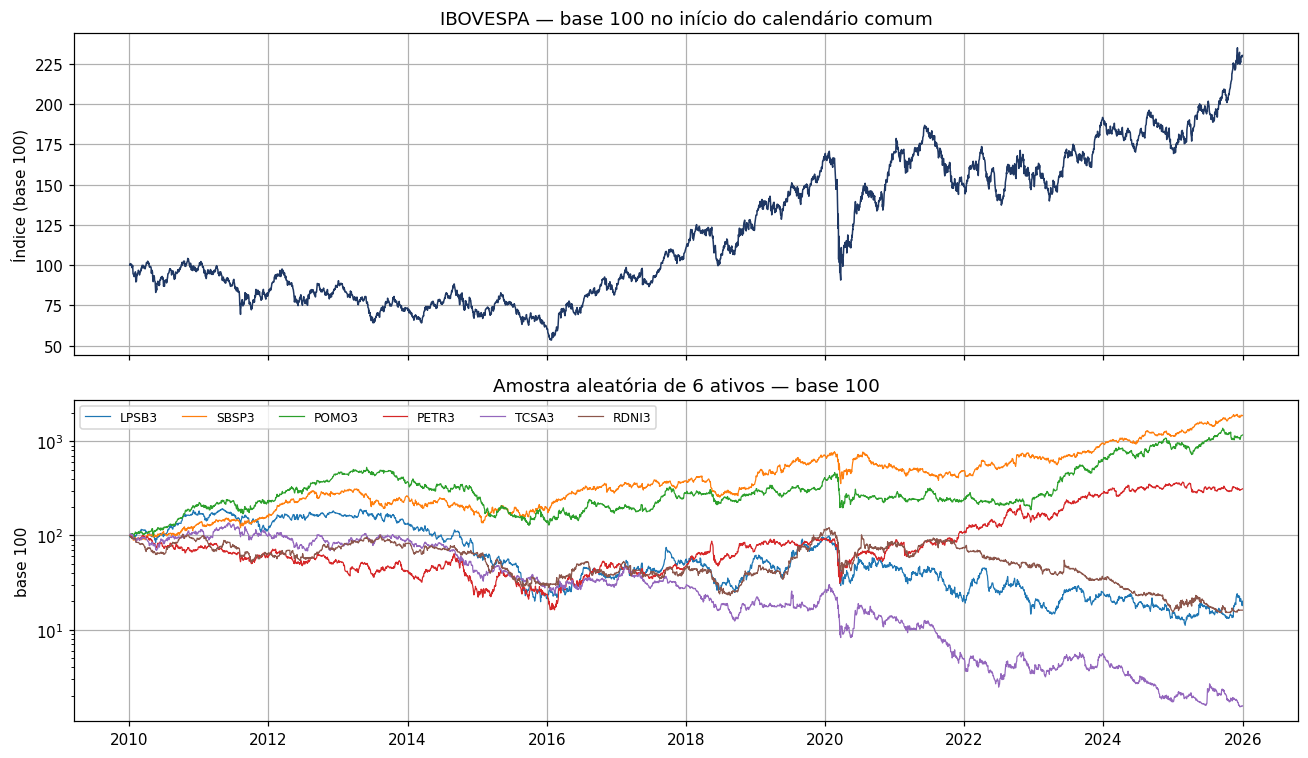

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
base100_ibov = painel["IBOV_close"] / painel["IBOV_close"].iloc[0] * 100
axes[0].plot(painel.index, base100_ibov, color="#1F3864", lw=1.0)
axes[0].set_title("IBOVESPA — base 100 no início do calendário comum")
axes[0].set_ylabel("Índice (base 100)")

np.random.seed(7)
amostra_tk = np.random.choice(acoes_cols, 6, replace=False)
for c in amostra_tk:
    serie = painel[c] / painel[c].iloc[0] * 100
    axes[1].plot(painel.index, serie, lw=0.8, label=c.replace("ACAO_",""))
axes[1].set_title("Amostra aleatória de 6 ativos — base 100")
axes[1].set_ylabel("base 100"); axes[1].set_yscale("log"); axes[1].legend(ncol=6, fontsize=8)
plt.tight_layout(); plt.show()


### 5.3 CDI e SELIC anualizados no calendário comum

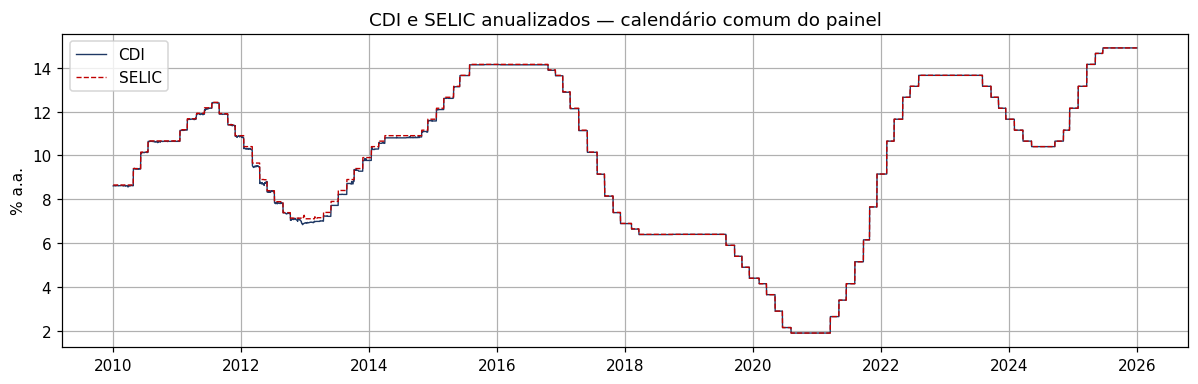

In [14]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(painel.index, ((1+painel["CDI_diario"])**252 - 1)*100, lw=0.9, color="#1F3864", label="CDI")
ax.plot(painel.index, ((1+painel["SELIC_diario"])**252 - 1)*100, lw=0.9, color="#C00000", ls="--", label="SELIC")
ax.set_title("CDI e SELIC anualizados — calendário comum do painel")
ax.set_ylabel("% a.a."); ax.legend()
plt.tight_layout(); plt.show()


## 6. Apêndice para o TCC — texto de redação

> **Etapa VI — Filtro de integridade de série.** Após a aplicação dos filtros de liquidez (Etapa IV,
> presença em pregão ≥ 95%) e de janela (Etapa V, primeiro pregão real anterior ao início do
> período de análise), procedeu-se a um sexto filtro destinado a remover ativos cuja série de preço
> ajustado por proventos foi distorcida por eventos societários múltiplos — notadamente grupamentos
> sucessivos em empresas sob recuperação judicial — não capturados adequadamente pela rotina de
> ajuste da fonte de dados. O critério objetivo adotado foi a exclusão de ativos com preço máximo
> ajustado superior a R$ 1.000, patamar incompatível com a prática de mercado das ações ordinárias
> brasileiras, cujas emissoras realizam desdobramentos para preservar a liquidez. Nove ativos foram
> excluídos por este critério (Tabela X), todos correspondentes a empresas com histórico de eventos
> societários patológicos. A amostra final resultou em 122 ativos. Ativos com elevada volatilidade
> diária mas preços compatíveis com o mercado foram mantidos, por constituírem informação econômica
> legítima e não erro de dados.
>
> **Alinhamento temporal.** As séries de preços dos 122 ativos, do IBOVESPA, do CDI e da SELIC foram
> alinhadas pela interseção estrita de seus calendários de pregão, resultando em [N] pregões comuns
> no período de [data inicial] a [data final]. A abordagem por interseção, em detrimento do
> preenchimento de valores ausentes, assegura que todas as estimativas subsequentes de média,
> variância e covariância sejam computadas sobre observações efetivamente registradas.